---

##**Aluna:** Ana Clara Fortunato de Souza

##**Matrícula:** 202302520

##**Disciplina:** Laboratório de Inovação e Automação (LIA)


##**Atividade:** Analisar um Dataset do Kaggle


Notebook desenvolvido por: <a href="https://lattes.cnpq.br/0212184185330718">Ana Clara Fortunato de Souza</a>



Datset Escolhido: <a href="https://www.kaggle.com/datasets/spscientist/students-performance-in-exams">Students Performance in Exams</a>

---

# **Análise de Desempenho de Estudantes**

Este projeto realiza uma análise exploratória de dados utilizando o dataset
Students Performance in Exams disponível no Kaggle.

O objetivo é entender quais fatores podem influenciar o desempenho dos
estudantes em matemática, leitura e escrita.

Serão analisadas variáveis como:
- gênero
- nível de educação dos pais
- tipo de alimentação
- curso de preparação para provas

## Perguntas de Análise

Para orientar esta análise exploratória de dados, foram definidas algumas
perguntas que serão investigadas ao longo do notebook:

1. Existe diferença no desempenho acadêmico entre estudantes de gêneros diferentes?

2. O curso de preparação para testes influencia as notas dos estudantes?

3. Qual é a relação entre as notas de matemática, leitura e escrita?

4. O nível de educação dos pais está associado ao desempenho dos estudantes?

5. Existe alguma diferença no desempenho dos alunos de acordo com o tipo de alimentação (lunch)?

6. Qual disciplina apresenta maior variação nas notas entre os estudantes?

7. Qual é a distribuição geral das notas e da média dos estudantes?

Ao longo desta análise exploratória, visualizações e estatísticas serão
utilizadas para responder a essas perguntas e identificar possíveis
padrões nos dados.

---

# **Carregando e Preparando os Dados**

In [ ]:
# Importando as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


# **1. 🧹 Limpeza dos dados**

In [ ]:
# Verificando dados repetidos
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


---

# **2. 📊 Análise exploratória**

Distribuição das notas

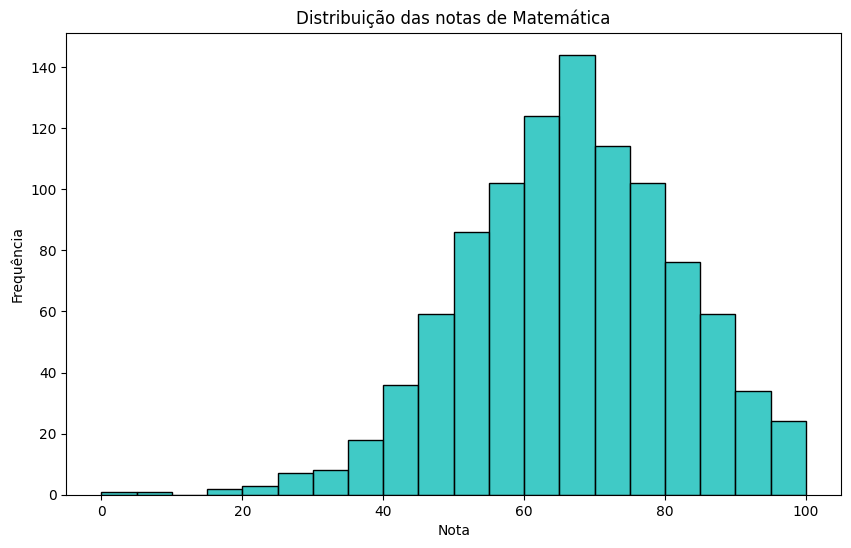

In [ ]:
# Histograma - Distribuição das notas de Matemática
plt.figure(figsize=(10, 6))

# Criando o Histograma com Seaborn
sns.histplot(df["math score"], bins=20, color= "#00B9B3")

plt.title("Distribuição das notas de Matemática")
plt.xlabel("Nota")
plt.ylabel("Frequência")

plt.show()

Comparação entre notas

In [ ]:
df[["math score","reading score","writing score"]].mean()

,0
math score,66.089
reading score,69.169
writing score,68.054


---

# **3. 📈 Visualizações informativas**

Notas por gênero

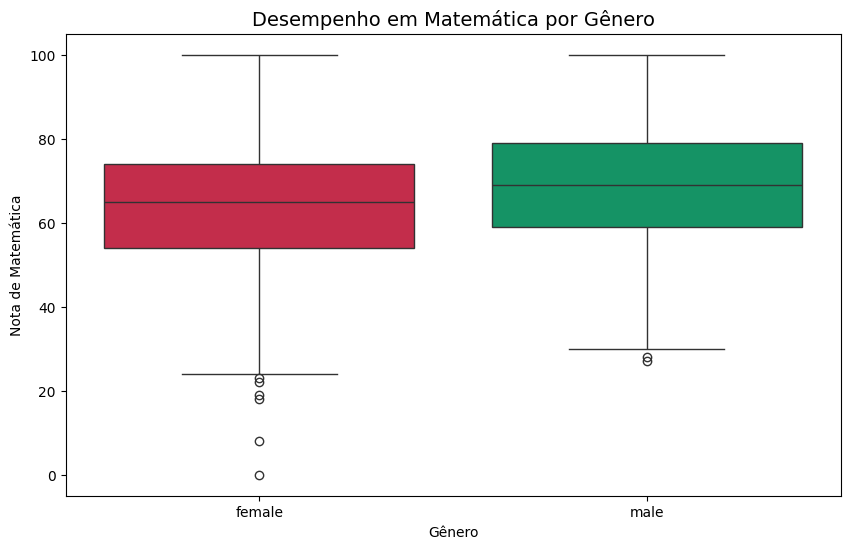

In [ ]:
# Boxplot - Nota de Matemática por Gênero
plt.figure(figsize=(10, 6))

# Criando o boxplot com Seaborn
sns.boxplot(
    x="gender",
    y="math score",
    data=df,
    hue="gender",
    palette=["#DC143C", "#00A86B"],
    legend=False
)


plt.title("Desempenho em Matemática por Gênero", fontsize=14)
plt.xlabel("Gênero")
plt.ylabel("Nota de Matemática")

df["gender"] = df["gender"].replace({
    "male": "Masculino",
    "female": "Feminino"
})


plt.show()

---

Média das notas dos estudantes

In [ ]:
df["Pontuação Média"] = (df["math score"] +
                       df["reading score"] +
                       df["writing score"]) / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Pontuação Média
0,Feminino,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,Feminino,group C,some college,standard,completed,69,90,88,82.333333
2,Feminino,group B,master's degree,standard,none,90,95,93,92.666667
3,Masculino,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,Masculino,group C,some college,standard,none,76,78,75,76.333333


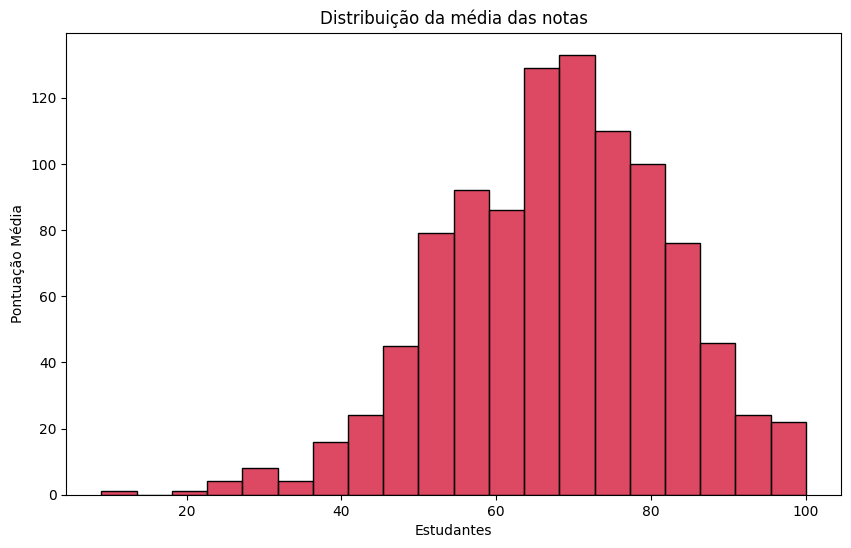

In [ ]:
# Histograma - Distribuição de média das notas
plt.figure(figsize=(10, 6))

# Criando o Histograma
sns.histplot(df["Pontuação Média"], bins=20, color="#D20A2E")
plt.title("Distribuição da média das notas")

plt.xlabel("Estudantes")
plt.ylabel("Pontuação Média")

plt.show()

Influência do curso de preparação

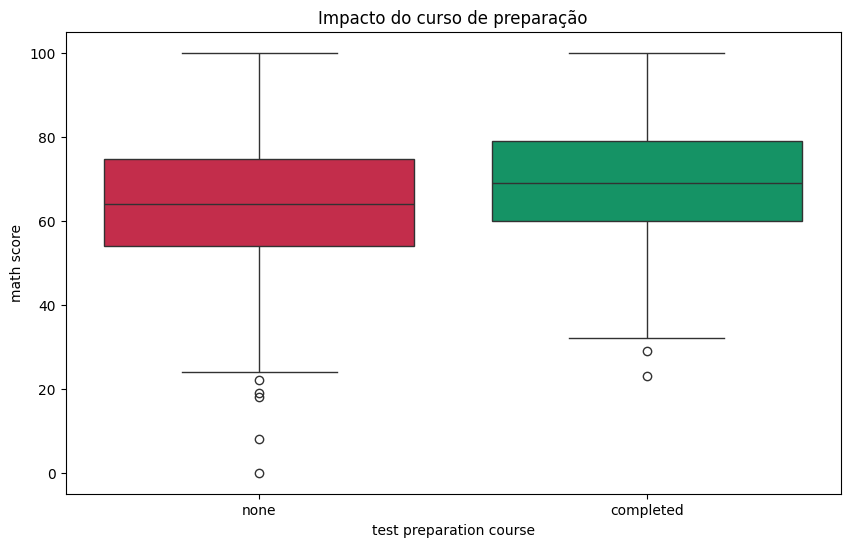

In [ ]:
# Boxplot - Nota de Matemática por Gênero
plt.figure(figsize=(10, 6))

# Criando o boxplot com Seaborn
sns.boxplot(x="test preparation course", y="math score",
            data=df,
            hue= "test preparation course",
            palette=["#DC143C", "#00A86B"])

plt.title("Impacto do curso de preparação")

plt.show()

Correlação entre matérias

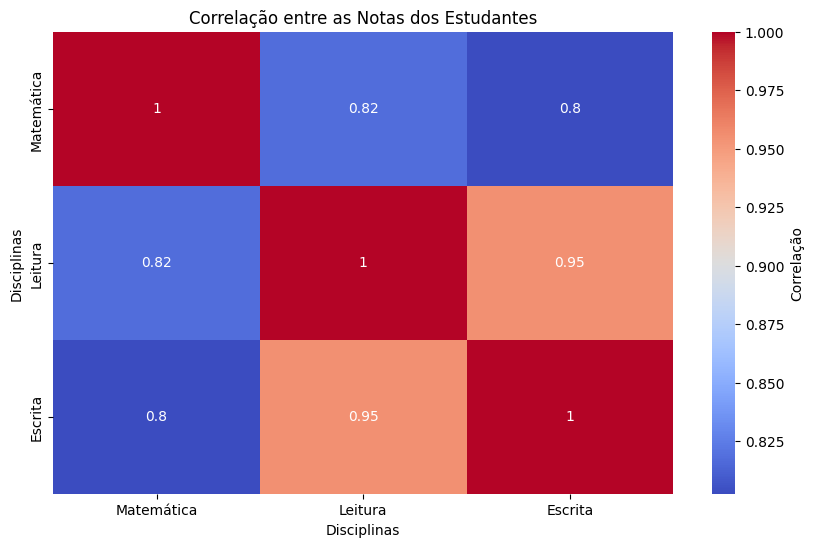

In [ ]:
# Headmap - Correlação entre notas
plt.figure(figsize=(10, 6))

# Renomeando as colunas
df = df.rename(columns={
    "math score": "Matemática",
    "reading score": "Leitura",
    "writing score": "Escrita"
})

# Criando o Headmap com Seaborn
sns.heatmap(
    df[["Matemática","Leitura","Escrita"]].corr(),
    annot=True,
    cmap="coolwarm",
    cbar_kws={"label": "Correlação"}
)

plt.title("Correlação entre as Notas dos Estudantes")
plt.xlabel("Disciplinas")
plt.ylabel("Disciplinas")

plt.show()


---

# **4. 🔍 Identificação de insights**

## Insights

1. Estudantes que completaram o curso de preparação tiveram notas maiores.
2. Existe forte correlação entre leitura e escrita.
3. A média de leitura é ligeiramente maior que matemática.
4. O nível de educação dos pais pode influenciar no desempenho dos alunos.

---

# **5. 📋 Conclusões e recomendações**

## 🎯 FATORES IMPORTANTES IDENTIFICADOS (por ordem de impacto):

### 1️⃣ GÊNERO:

👩 Estudantes do gênero feminino:
- Melhor desempenho em **leitura**
- Melhor desempenho em **escrita**

👨 Estudantes do gênero masculino:
- Desempenho ligeiramente maior em **matemática**

📊 Diferenças moderadas entre as disciplinas.

---

### 2️⃣ CURSO DE PREPARAÇÃO:

📚 Com preparação: média mais alta nas três disciplinas  
📖 Sem preparação: médias significativamente menores  
📊 Diferença média observada nas notas: aumento perceptível no desempenho

---

## 3️⃣ 📊 DISCIPLINAS

📐 Matemática:
- Maior variação de notas entre estudantes

📖 Leitura:
- Distribuição mais concentrada

✍️ Escrita:
- Forte relação com desempenho em leitura

---


### 4️⃣ EDUCAÇÃO DOS PAIS:

🎓 Pais com ensino superior ou mestrado:
- Estudantes com **médias mais altas**

📘 Pais com menor nível educacional:
- Médias ligeiramente menores

📊 Indica possível influência do ambiente educacional familiar.

---

### 5️⃣ TIPO DE ALIMENTAÇÃO (LUNCH):

🍽️ Standard lunch:
- Associado a **melhor desempenho médio**

🥪 Free/Reduced lunch:
- Médias ligeiramente menores

📊 Pode refletir fatores socioeconômicos que impactam o desempenho acadêmico.

---



## 6️⃣ 🚨 CASOS OBSERVADOS

⭐ Estudantes com preparação para testes + ambiente educacional favorável  
➡ Tendem a apresentar **as maiores médias gerais**

⚠ Estudantes sem preparação para testes  
➡ Tendem a apresentar **maior risco de notas mais baixas**

---

## 💡 LIÇÕES APRENDIDAS

✅ Visualizações ajudam a identificar padrões importantes nos dados  
✅ Diferentes fatores educacionais podem influenciar o desempenho acadêmico  
✅ Existe forte relação entre habilidades de leitura e escrita  
✅ Preparação para provas pode impactar positivamente os resultados  


## **Recomendações**

Com base nos resultados obtidos, algumas recomendações podem ser feitas:

- Incentivar a participação dos estudantes em cursos de preparação para testes, já que os dados indicam que alunos que realizaram esse tipo de preparação tendem a apresentar melhores médias.
- Desenvolver estratégias educacionais que fortaleçam habilidades de leitura, pois há forte relação entre desempenho em leitura e escrita.
- Criar programas de apoio acadêmico para estudantes com menor desempenho em matemática, disciplina que apresentou maior variação nas notas.
- Estimular o acompanhamento educacional no ambiente familiar, visto que o nível de educação dos pais pode estar associado ao desempenho dos alunos.

Essas ações podem contribuir para melhorar o desempenho acadêmico geral e reduzir desigualdades no aprendizado.

---

## **Conclusão**

A análise mostrou que fatores como preparação para testes e contexto
familiar podem influenciar o desempenho dos estudantes.

Além disso, as notas de leitura e escrita possuem forte correlação,
indicando que estudantes bons em leitura tendem a ter bom desempenho
em escrita.
